# Candy & Tea Order Predictor

A time series regression model used to predict the ordering frequency for candy

Future goal: modifying the data to also predict tea orders as well

## Imports
The packages needed to run the model

In [77]:
# Imports
print('This is a test')

import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
# Maybe I'll switch to SVR, we'll see how it goes... LassoCV is another option too
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
#NOTE: This is for testing cross validation later... deal with this later
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt




This is a test


## Data Prep

In [78]:
# Train & Validation Data Setup

file_path = 'data/candy_data.csv'
df = pd.read_csv('data/candy_data.csv')
print(df.head())

# creating the structure for the model
# I want to filter for whatever item I assess (ex: candy, tea, etc.)
df['item'] = df['item'].str.lower().str.strip()
df['is_candy'] = df['item'].str.contains(r'\bcandy\b', regex=True, na=False)

# additional data cleaning
df['cost'] = df['cost'].str.replace('USD', ' ').astype(float)
df['req_date'] = pd.to_datetime(df['req_date'])

# defining filtered candy dataframe
candy_df = df[df['is_candy']]
#NOTE: this code converts the req_date to a datetime object for time series purposes 
candy_df['req_date'] = pd.to_datetime(candy_df['req_date'])
candy_df = candy_df.set_index('req_date')
print(candy_df.index)
#NOTE: we are going to test weekly vs monthly date counts to see which gives a better regression
weekly = candy_df.resample('W').size().reset_index(name='order_count')
monthly = candy_df.resample('ME').size().reset_index(name='order_count')

print(candy_df.head())

    item            req_id   req_date requester    status budget_status  \
0  candy  NWUNV/REQ2302418  4/28/2026   QDR0260  Complete         Valid   
1    tea  NWUNV/REQ2297481  4/15/2026   QDR0260  Complete         Valid   
2  candy  NWUNV/REQ2296641  4/13/2026   QDR0260  Complete         Valid   
3    tea  NWUNV/REQ2293614   4/4/2026   QDR0260  Complete         Valid   
4  candy  NWUNV/REQ2292744   4/1/2026   QDR0260  Complete         Valid   

         cost  
0  184.17 USD  
1   63.08 USD  
2  420.01 USD  
3   63.08 USD  
4  205.25 USD  
DatetimeIndex(['2026-04-28', '2026-04-13', '2026-04-01', '2026-03-02',
               '2026-02-19', '2026-02-09', '2026-01-24', '2026-01-15',
               '2026-01-06', '2025-10-21', '2026-07-16', '2026-06-04',
               '2026-05-18', '2026-05-01', '2026-04-28', '2025-10-01',
               '2025-09-24', '2025-08-21', '2025-08-05', '2025-07-15',
               '2025-06-16', '2025-05-22', '2025-05-15', '2025-05-12',
               '2025-05-06'

## Model!

In [84]:
# Features prep
# Prepare Train Data

# engineered features
monthly['time_idx'] = range(len(monthly))
# monthly['month'] = monthly['req_date'].dt.month
# monthly['lag_1'] = monthly['order_count'].shift(1)
# monthly = monthly.dropna()
# monthly = monthly.reset_index(drop=True)

# print(monthly.tail(8))

# predicting value
y = monthly['order_count']
X = monthly[['time_idx']]

#shuffle is False becuase this is a time series that relies on the chronological date data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

model= LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test) 

# Time Series cross validation experiment
tcsv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X, y, cv=tcsv, scoring='r2')
print(scores)

[-0.95067149 -0.10353395  0.00847692 -3.46293    -0.11003979]


In [85]:
# Model Exaluation metrics
mse = mean_squared_error(y_test, y_pred)** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.2f}, MAE: {mae:.2f}, R2: {r2:.2f}')

# Seeing what the actual values look like for the pred/actual data
print(y_test.values)
print(y_pred)

MSE: 1.29, MAE: 1.05, R2: -0.15
[2 0 0 3 2 1 4 2 1 1]
[1.97936508 2.0022737  2.02518233 2.04809095 2.07099957 2.09390819
 2.11681682 2.13972544 2.16263406 2.18554269]


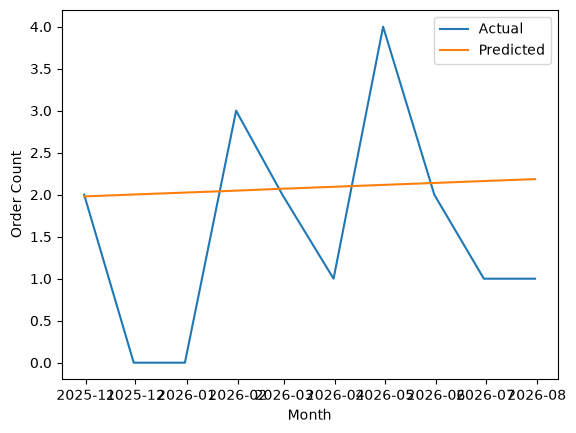

In [86]:
# plot evaluation
plt.plot(monthly['req_date'].iloc[-len(y_test):], y_test.values, label='Actual')
plt.plot(monthly['req_date'].iloc[-len(y_test):], y_pred, label='Predicted')
plt.legend()
plt.xlabel('Month')
plt.ylabel('Order Count')
plt.show()

## Evaluation Progress Notes

Baseline
- Weekly metric
- MSE: 0.61
- MAE: 0.51
- R^2 = 0.06
- Evaluation: Weekly is definitely not the right metric to use, as the average value on the graph is 0 - 0.5 orders per week. That doesn't make any sense, so the monthly metric may perform better. But the MSE is also not... good.

Experiment #1
- Monthly Metric
- MSE: 1.27
- MAE: 1.09
- R^2: -0.03
- Evaluation: ok, that just made it so much worse. welp... I think a major issue is not having enough data. But this is all the data I have to work with so I am a little stumped. 

Experiment #2
- Monthly metric
- Changing the train/test split to 70/30 instead of 80/20
- MSE: 1.40
- MAE: 1.20
- R^2: -0.77
- Evaluation: oh so it got even worse, nice. So let's not do that. 

Experiment #3
- Monthly metric
- Adding a Time Series Split, something recommended by Claude. 
- What is it supposed to do? Evaluate if every single train/test split is bad 
- because if it is, it's not the model, it's the data being too random that's messing up the model. 
- MSE: 1.25
- MAE: 1.06
- R^2: 0.01
- Evaluation:  This helped discover that the data is not reliable. It is not the model. It's the data. 

Experiment #4
- Monthly metric
- Simplified the model drastically, no data cutoff, no scaler. 
- MSE: 1.29
- MAE: 1.05
- R^2: -0.15
- Evaluation: Even though the model's accuracy is horrendous because of the data being random ,
- it found the trend I was looking for, where it is approx 2 candy orders/month!
- however, one thing I could maybe try is casting not just the test data but all data on the graph to see the regression vs the trending months. 